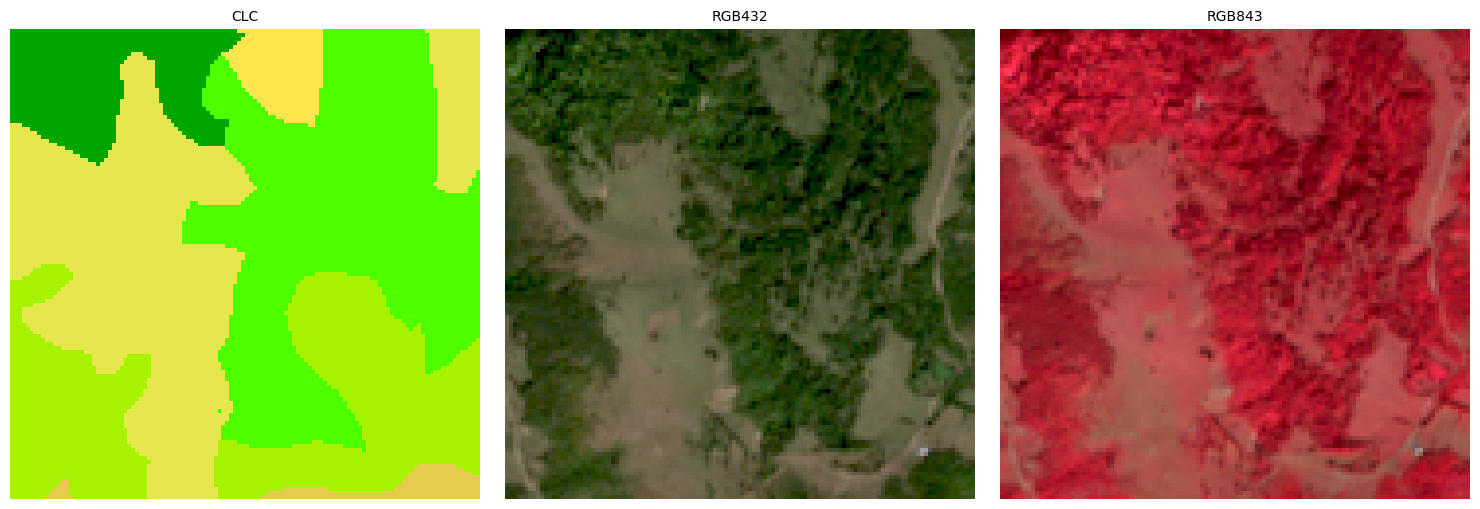

Index:        1269
BaseFolder:   S2A_MSIL2A_20180928T090731_N0500_R050_T35TMM
BaseFilename: S2A_MSIL2A_20180928T090731_N0500_R050_T35TMM_5599_6146
Split:        train
caption1: forest and semi-natural zones, agricultural areas
caption2: forests, pastures, scrub and/or herbaceous vegetation associations, heterogeneous agricultural areas
caption3: mixed forest, pastures, transitional woodland-shrub, coniferous forest, complex cultivation patterns
caption4: mixed forest, pastures, transitional woodland-shrub, coniferous forest, complex cultivation patterns
caption5: forest, pastures, shrubland, mixed farmland



In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Single-size PNG patch visualizer
================================

• Asks once for patch size (64–336)
• Loads metadata_<size>.parquet from:
    /dataset_root/PNG/Patch_<size>/
• Displays CLC / RGB432 / RGB843 triplets
• Prints all 5 captions + split (train/val/test)
"""

# =============================================================================
# IMPORTS
# =============================================================================
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

# =============================================================================
# CONFIGURATION
# =============================================================================
ROOT_DIR = "/dataset_root/PNG"

# Ask for patch size once ------------------------------------------------------
while True:
    try:
        patch_size = int(input("Enter patch size (64–336): ").strip())
        patch_dir = os.path.join(ROOT_DIR, f"Patch_{patch_size}")
        parquet_path = os.path.join(patch_dir, f"metadata_{patch_size}.parquet")
        if os.path.exists(parquet_path):
            break
        else:
            print(f"❌ metadata_{patch_size}.parquet not found in {patch_dir}")
    except ValueError:
        pass
    print("Please enter a valid patch size (64–336).")

# Load metadata ---------------------------------------------------------------
try:
    df = pd.read_parquet(parquet_path)
except Exception as e:
    raise RuntimeError(f"Error loading {parquet_path}: {e}")

print(f"\n✅ Loaded {os.path.basename(parquet_path)} with {len(df)} rows.\n")

idx = 0

# =============================================================================
# MAIN LOOP
# =============================================================================
while True:
    inp = input("Enter row number, 'n'=next, 'p'=prev, 'q'=quit: ").strip().lower()

    if inp == "q":
        print("Quitting.")
        break
    elif inp == "" or inp == "n":
        idx = min(idx + 1, len(df) - 1)
    elif inp == "p":
        idx = max(idx - 1, 0)
    elif inp.isdigit():
        val = int(inp)
        if 0 <= val < len(df):
            idx = val
        else:
            print(f"Row number must be in range [0, {len(df)-1}]")
            continue
    else:
        print("Invalid input.")
        continue

    # -------------------------------------------------------------------------
    # LOAD IMAGES
    # -------------------------------------------------------------------------
    row = df.iloc[idx]
    base_folder = row["BaseFolder"]
    base_filename = row["BaseFilename"]

    paths = [
        os.path.join(patch_dir, "CLC_reference_RGB", base_folder, f"{base_filename}_CLC_RGB.png"),
        os.path.join(patch_dir, "TrueColor_RGB", base_folder, f"{base_filename}_B432.png"),
        os.path.join(patch_dir, "FalseColor_NIR", base_folder, f"{base_filename}_B843.png"),
    ]
    labels = ["CLC", "RGB432", "RGB843"]

    images, titles = [], []
    for path, label in zip(paths, labels):
        if os.path.exists(path):
            arr = cv2.imread(path, cv2.IMREAD_COLOR)
            arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
            images.append(arr)
        else:
            images.append(None)
        titles.append(label)

    # -------------------------------------------------------------------------
    # DISPLAY IMAGES
    # -------------------------------------------------------------------------
    clear_output(wait=False)
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, title in zip(axs, images, titles):
        if img is not None:
            ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # PRINT CAPTIONS + SPLIT
    # -------------------------------------------------------------------------
    print("=" * 80)
    print(f"Index:        {idx}")
    print(f"BaseFolder:   {base_folder}")
    print(f"BaseFilename: {base_filename}")
    print(f"Split:        {row.get('split', 'unknown')}")
    print("=" * 80)

    for i in range(1, 6):
        cap_col = f"caption{i}"
        val = row.get(cap_col)
        if pd.isna(val) or str(val).strip() == "":
            print(f"{cap_col}: (missing)")
        else:
            print(f"{cap_col}: {val}")
    print("=" * 80 + "\n")
